# Nursery: package-executed Multi-IMV example

This notebook executes `imv.MulticlassIMV` on the local processed dataset and creates both figures from the fresh fold results. No result pickle is loaded. Three shuffled folds keep the notebook interactive; use ten folds and the documented seeds for full paper reproduction.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imv import MulticlassIMV
HERE=Path.cwd(); DATA=HERE.parent/"data"; FIGURES=HERE/"figures"; FIGURES.mkdir(exist_ok=True)

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
data=pd.read_csv(DATA/"nursery_processed.csv")
features=[column for column in data.columns if column!="target"]
print(data.shape, features, sorted(data["target"].unique()))
data.head()

(12630, 9) ['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health'] [0, 1, 2]


,parents,has_nurs,form,children,housing,finance,social,health,target
0,2,3,0,0,0,0,0,1,1
1,2,3,0,0,0,0,0,0,0
2,2,3,0,0,0,0,2,1,1
3,2,3,0,0,0,0,2,0,0
4,2,3,0,0,0,0,1,2,1


In [3]:
evaluator=MulticlassIMV(data,"target",lambda:LogisticRegression(max_iter=2000,random_state=42),n_splits=3,optional_explanatory_variables=features,random_state=42,stratified=False,verbose=False)
ova_folds,ova_mean=evaluator.k_fold_one_vs_all()
matrix_folds,matrix_mean=evaluator.k_fold_imv_matrix()
pd.DataFrame({"class":matrix_mean.index,"one_vs_rest_imv":ova_mean})

,class,one_vs_rest_imv
0,0,0.519174
1,1,0.309994
2,2,0.275442


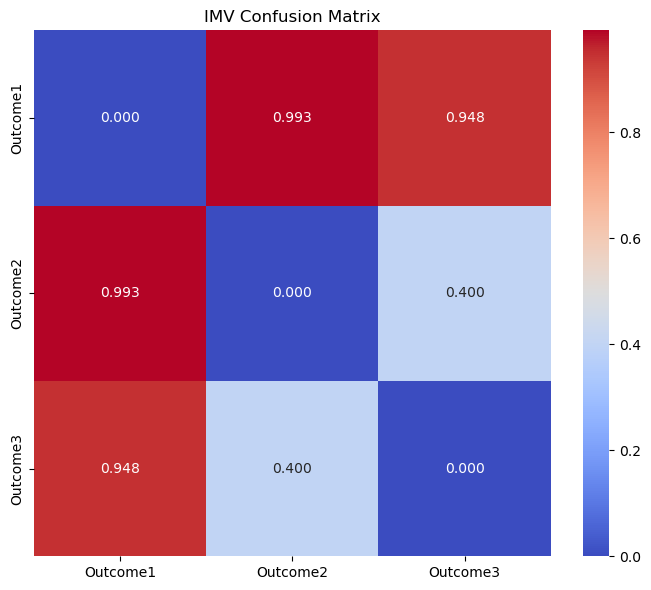

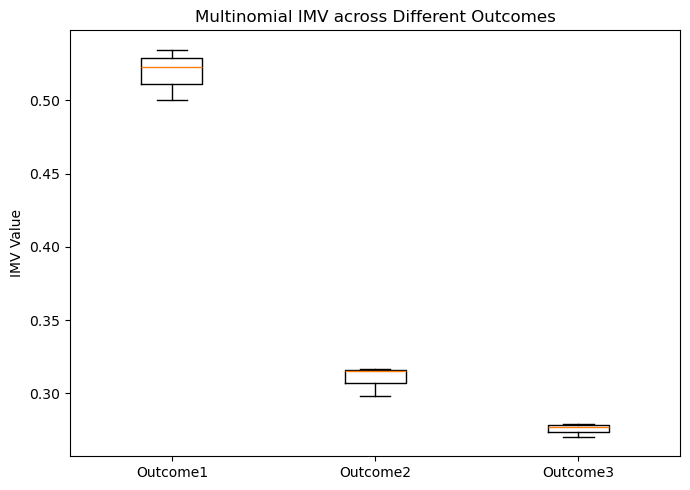

(PosixPath('/Users/valler/Python/imv_ml_package/examples/multi_imv/figures/multi_imv_nursery_package_heatmap.png'),
 PosixPath('/Users/valler/Python/imv_ml_package/examples/multi_imv/figures/multi_imv_nursery_package_boxplot.png'))

In [4]:
fig1,ax1=evaluator.multinomial_IMV_heatmap(matrix_mean,figsize=(7,6)); fig1.tight_layout(); heatmap_path=FIGURES/"multi_imv_nursery_package_heatmap.png"; fig1.savefig(heatmap_path,dpi=180,bbox_inches="tight"); plt.show()
fig2,ax2=evaluator.multinomial_IMV_boxplot(ova_folds,figsize=(7,5)); fig2.tight_layout(); boxplot_path=FIGURES/"multi_imv_nursery_package_boxplot.png"; fig2.savefig(boxplot_path,dpi=180,bbox_inches="tight"); plt.show()
heatmap_path,boxplot_path